### Telecom company management aims to reduce customer churn and revenue loss by identifying customers who are likely to leave and applying strategic retention decisions.

In [2]:
%pip install imbalanced-learn

Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from imblearn.over_sampling import SMOTE
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt


In [4]:
df = pd.read_csv('churn.csv')
df.head()

,state,account length,area code,phone number,international plan,voice mail plan,number vmail messages,total day minutes,total day calls,total day charge,...,total eve calls,total eve charge,total night minutes,total night calls,total night charge,total intl minutes,total intl calls,total intl charge,customer service calls,churn
0,KS,128,415,382-4657,no,yes,25,265.1,110,45.07,...,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,371-7191,no,yes,26,161.6,123,27.47,...,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,358-1921,no,no,0,243.4,114,41.38,...,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,375-9999,yes,no,0,299.4,71,50.90,...,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,330-6626,yes,no,0,166.7,113,28.34,...,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


### FAMILIARIZE WITH THE DATASET

In [5]:
len(df)

3333

In [6]:
df.head()

,state,account length,area code,phone number,international plan,voice mail plan,number vmail messages,total day minutes,total day calls,total day charge,...,total eve calls,total eve charge,total night minutes,total night calls,total night charge,total intl minutes,total intl calls,total intl charge,customer service calls,churn
0,KS,128,415,382-4657,no,yes,25,265.1,110,45.07,...,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,371-7191,no,yes,26,161.6,123,27.47,...,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,358-1921,no,no,0,243.4,114,41.38,...,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,375-9999,yes,no,0,299.4,71,50.90,...,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,330-6626,yes,no,0,166.7,113,28.34,...,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


In [7]:
df.describe()

,account length,area code,number vmail messages,total day minutes,total day calls,total day charge,total eve minutes,total eve calls,total eve charge,total night minutes,total night calls,total night charge,total intl minutes,total intl calls,total intl charge,customer service calls
count,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000
mean,101.064806,437.182418,8.099010,179.775098,100.435644,30.562307,200.980348,100.114311,17.083540,200.872037,100.107711,9.039325,10.237294,4.479448,2.764581,1.562856
std,39.822106,42.371290,13.688365,54.467389,20.069084,9.259435,50.713844,19.922625,4.310668,50.573847,19.568609,2.275873,2.791840,2.461214,0.753773,1.315491
min,1.000000,408.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,23.200000,33.000000,1.040000,0.000000,0.000000,0.000000,0.000000
25%,74.000000,408.000000,0.000000,143.700000,87.000000,24.430000,166.600000,87.000000,14.160000,167.000000,87.000000,7.520000,8.500000,3.000000,2.300000,1.000000
50%,101.000000,415.000000,0.000000,179.400000,101.000000,30.500000,201.400000,100.000000,17.120000,201.200000,100.000000,9.050000,10.300000,4.000000,2.780000,1.000000
75%,127.000000,510.000000,20.000000,216.400000,114.000000,36.790000,235.300000,114.000000,20.000000,235.300000,113.000000,10.590000,12.100000,6.000000,3.270000,2.000000
max,243.000000,510.000000,51.000000,350.800000,165.000000,59.640000,363.700000,170.000000,30.910000,395.000000,175.000000,17.770000,20.000000,20.000000,5.400000,9.000000


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3333 entries, 0 to 3332
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   state                   3333 non-null   object 
 1   account length          3333 non-null   int64  
 2   area code               3333 non-null   int64  
 3   phone number            3333 non-null   object 
 4   international plan      3333 non-null   object 
 5   voice mail plan         3333 non-null   object 
 6   number vmail messages   3333 non-null   int64  
 7   total day minutes       3333 non-null   float64
 8   total day calls         3333 non-null   int64  
 9   total day charge        3333 non-null   float64
 10  total eve minutes       3333 non-null   float64
 11  total eve calls         3333 non-null   int64  
 12  total eve charge        3333 non-null   float64
 13  total night minutes     3333 non-null   float64
 14  total night calls       3333 non-null   

### ONE HOT ENCODE CATEGORICAL COLUMNS

In [9]:
df_encoded = pd.get_dummies(df, columns=[ 'international plan', 'voice mail plan', 'area code'], drop_first=True)
df_encoded

,state,account length,phone number,number vmail messages,total day minutes,total day calls,total day charge,total eve minutes,total eve calls,total eve charge,...,total night charge,total intl minutes,total intl calls,total intl charge,customer service calls,churn,international plan_yes,voice mail plan_yes,area code_415,area code_510
0,KS,128,382-4657,25,265.1,110,45.07,197.4,99,16.78,...,11.01,10.0,3,2.70,1,False,False,True,True,False
1,OH,107,371-7191,26,161.6,123,27.47,195.5,103,16.62,...,11.45,13.7,3,3.70,1,False,False,True,True,False
2,NJ,137,358-1921,0,243.4,114,41.38,121.2,110,10.30,...,7.32,12.2,5,3.29,0,False,False,False,True,False
3,OH,84,375-9999,0,299.4,71,50.90,61.9,88,5.26,...,8.86,6.6,7,1.78,2,False,True,False,False,False
4,OK,75,330-6626,0,166.7,113,28.34,148.3,122,12.61,...,8.41,10.1,3,2.73,3,False,True,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3328,AZ,192,414-4276,36,156.2,77,26.55,215.5,126,18.32,...,12.56,9.9,6,2.67,2,False,False,True,True,False
3329,WV,68,370-3271,0,231.1,57,39.29,153.4,55,13.04,...,8.61,9.6,4,2.59,3,False,False,False,True,False
3330,RI,28,328-8230,0,180.8,109,30.74,288.8,58,24.55,...,8.64,14.1,6,3.81,2,False,False,False,False,True
3331,CT,184,364-6381,0,213.8,105,36.35,159.6,84,13.57,...,6.26,5.0,10,1.35,2,False,True,False,False,True


## DROP PHONE NUMBER COLUMN

In [10]:
df_encoded.drop(columns='phone number', inplace=True)
#its not necessary

In [11]:
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3333 entries, 0 to 3332
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   state                   3333 non-null   object 
 1   account length          3333 non-null   int64  
 2   number vmail messages   3333 non-null   int64  
 3   total day minutes       3333 non-null   float64
 4   total day calls         3333 non-null   int64  
 5   total day charge        3333 non-null   float64
 6   total eve minutes       3333 non-null   float64
 7   total eve calls         3333 non-null   int64  
 8   total eve charge        3333 non-null   float64
 9   total night minutes     3333 non-null   float64
 10  total night calls       3333 non-null   int64  
 11  total night charge      3333 non-null   float64
 12  total intl minutes      3333 non-null   float64
 13  total intl calls        3333 non-null   int64  
 14  total intl charge       3333 non-null   

### SPLIT TRAIN/TEST VALUES

In [12]:
x = df_encoded.drop(columns=['churn'])
y = df_encoded['churn']

x_train, x_test, y_train, y_test = train_test_split(x,y ,test_size=0.2, random_state=254)

## SCALE TRAIN/TEST VALUES
# XTRAIN IS FIT ON TRAINING NUMERIC FEATURES XTEST IS FIT ON TESTING NUMERIC FEATURES

In [13]:
scaler = StandardScaler()

x_train[x_train.select_dtypes(include=['int64', 'float64']).columns] = scaler.fit_transform(x_train.select_dtypes(include=['int64', 'float64']))

x_test[x_test.select_dtypes(include=['int64', 'float64']).columns] = scaler.transform(x_test.select_dtypes(include=['int64', 'float64']))

In [14]:
df_encoded['state'].unique()

array(['KS', 'OH', 'NJ', 'OK', 'AL', 'MA', 'MO', 'LA', 'WV', 'IN', 'RI',
       'IA', 'MT', 'NY', 'ID', 'VT', 'VA', 'TX', 'FL', 'CO', 'AZ', 'SC',
       'NE', 'WY', 'HI', 'IL', 'NH', 'GA', 'AK', 'MD', 'AR', 'WI', 'OR',
       'MI', 'DE', 'UT', 'CA', 'MN', 'SD', 'NC', 'WA', 'NM', 'NV', 'DC',
       'KY', 'ME', 'MS', 'TN', 'PA', 'CT', 'ND'], dtype=object)

## TARGET ENCODE STATE COLUMN

In [15]:
#cant one hot encode to avoid 50 new columns
state_means = x_train.join(y_train).groupby('state')['churn'].mean() ##map state to mean of churn in training set
global_mean = y_train.mean() ##backup value incase for test set values not seen in training set

x_train['state_encoded'] = x_train['state'].map(state_means)

x_test['state_encoded'] = x_test['state'].map(state_means).fillna(global_mean)

x_train = x_train.drop(columns='state')
x_test = x_test.drop(columns='state')

In [16]:

#print(x_train.dtypes)
print(x_train.isna().sum())

account length            0
number vmail messages     0
total day minutes         0
total day calls           0
total day charge          0
total eve minutes         0
total eve calls           0
total eve charge          0
total night minutes       0
total night calls         0
total night charge        0
total intl minutes        0
total intl calls          0
total intl charge         0
customer service calls    0
international plan_yes    0
voice mail plan_yes       0
area code_415             0
area code_510             0
state_encoded             0
dtype: int64


## LOGISTIC REGRESSION MODEL

In [17]:
model = LogisticRegression()
model.fit (x_train, y_train)

y_pred = model.predict(x_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.841079460269865
              precision    recall  f1-score   support

       False       0.85      0.98      0.91       551
        True       0.67      0.17      0.27       116

    accuracy                           0.84       667
   macro avg       0.76      0.58      0.59       667
weighted avg       0.82      0.84      0.80       667



# model identifies nonchurners well and almost all non churners 0.98 are correctly labelled
# model is terrible at identifying churners and catches only 17% of actual churners but when it predicts churn it is correct 67% of the time
# model is poor at predicting churn 27%

In [18]:
y_train.value_counts()

churn
False    2299
True      367
Name: count, dtype: int64

In [19]:
#coz the uneven distribution of majority and minority
smote = SMOTE(random_state=42)
x_train_res, y_train_res = smote.fit_resample(x_train, y_train) #Apply to training set only 
print(y_train_res.value_counts())

churn
False    2299
True     2299
Name: count, dtype: int64


In [20]:
model.fit(x_train_res, y_train_res)

y_preds = model.predict(x_test)
print(classification_report(y_test, y_preds))

              precision    recall  f1-score   support

       False       0.93      0.79      0.85       551
        True       0.42      0.73      0.53       116

    accuracy                           0.78       667
   macro avg       0.68      0.76      0.69       667
weighted avg       0.84      0.78      0.80       667



# model catches 79% of actual non churners slightly worse than before SMOTE
# model predicts churners 42% of the time lower than before SMOTE but it catches 73 % of actual churners
# model is much better at detectin churncers but with a trade off for precision predicting non churners

### DECISION TREE

In [21]:
smote = SMOTE(random_state=42)
X_res_2, y_res_2 = smote.fit_resample(x_train, y_train)

print("Before SMOTE:", y_train.value_counts())
print("After SMOTE:", pd.Series(y_res_2).value_counts())

Before SMOTE: churn
False    2299
True      367
Name: count, dtype: int64
After SMOTE: churn
False    2299
True     2299
Name: count, dtype: int64


In [22]:
dt = DecisionTreeClassifier(max_depth=5,min_samples_split=20,min_samples_leaf=10,max_features="sqrt",random_state=42)

dt.fit(X_res_2, y_res_2)
y_pred_dec = dt.predict(x_test)

y_pred_2 = dt.predict(x_test)



In [23]:

print(confusion_matrix(y_test, y_pred_2))
print(classification_report(y_test, y_pred_2))

print("Accuracy:", accuracy_score(y_test, y_pred_2))

[[497  54]
 [ 27  89]]
              precision    recall  f1-score   support

       False       0.95      0.90      0.92       551
        True       0.62      0.77      0.69       116

    accuracy                           0.88       667
   macro avg       0.79      0.83      0.81       667
weighted avg       0.89      0.88      0.88       667

Accuracy: 0.8785607196401799


# Predictions for non churners are high 95% and model identifies 90% of all actual nonchurners
# MODEL catches 77% of actual churners and of the predicted churners 62% actually churn


## WEIGHT OF EACH COLUMN CONTRIBUTION

In [24]:


feature_importance = pd.DataFrame({
    'column': x_train.columns,
    'importance': dt.feature_importances_
}).sort_values(by='importance', ascending=False)

print(feature_importance)

                    column  importance
14  customer service calls    0.330225
4         total day charge    0.254311
15  international plan_yes    0.246110
1    number vmail messages    0.042933
5        total eve minutes    0.038278
11      total intl minutes    0.029260
19           state_encoded    0.014085
12        total intl calls    0.013565
8      total night minutes    0.010013
2        total day minutes    0.007062
6          total eve calls    0.005321
7         total eve charge    0.004364
3          total day calls    0.004027
0           account length    0.000444
13       total intl charge    0.000000
9        total night calls    0.000000
16     voice mail plan_yes    0.000000
17           area code_415    0.000000
18           area code_510    0.000000
10      total night charge    0.000000


## VISUALISATION OF TREE

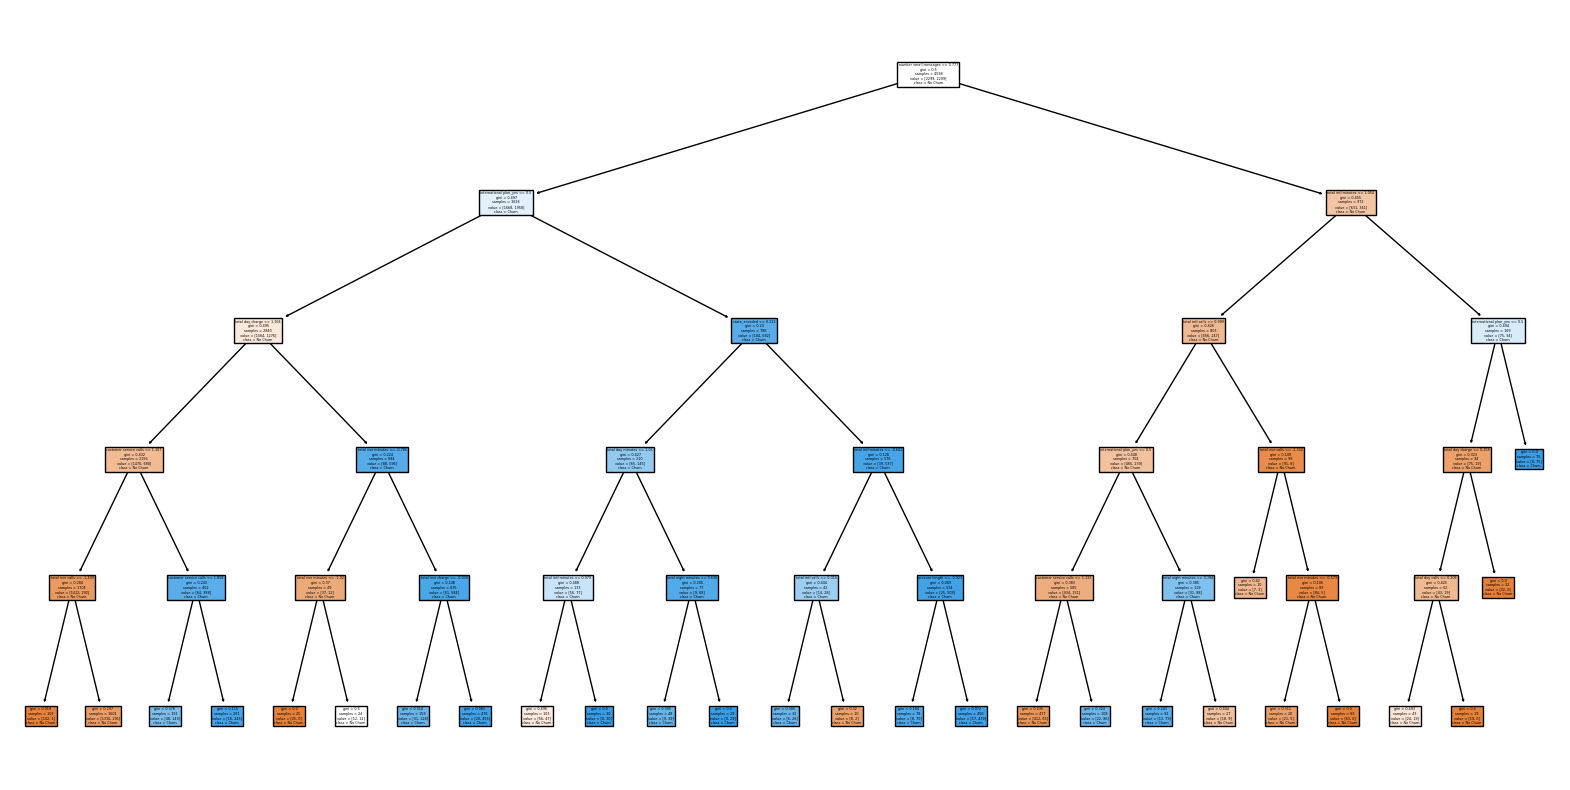

In [25]:


plt.figure(figsize=(20,10))
plot_tree(dt, feature_names=x_train.columns, class_names=['No Churn','Churn'], filled=True)
plt.show()




# RATIONALE:
# Features such as the number of customer service calls, total day charges, and whether a customer has an international plan are highly influential in determining churn. The dataset is imbalanced, with 116 churners and 551 non-churners, so SMOTE was applied to balance the classes and improve model performance on the minority class. A decision tree model was chosen because it can capture non-linear relationships and interactions between features, making it suitable for predicting churn.

# RESULTS
# Model predicts 77% of customers likely to churn correctly and 90% of non churners correctly meaning the company can proactively target potential churners without mislabelling many loyal customers.

# LIMITATIONS
# Some loyal customers may be flagged as churners leading to unnecessary retention strategies and customers with behaviour not captured in the data may be misclassified.

# RECOMMENDATIONS
# Leverage the model to identify customers at high risk of churn and target them with personalized retention strategies. Continuously monitor flagged customers and adjust interventions based on observed outcomes. Additionally, gather and incorporate more relevant customer data to enhance the model’s predictive accuracy over time.